# TrafficCamNet — Baseline Evaluation on BDD100K

**Модель:** TrafficCamNet ResNet-18 (DetectNet_v2), FP16 ONNX (NGC `pruned_onnx_v1.0.4`)
**Датасет:** BDD100K val (~10 000 изображений, Kaggle: [solesensei/solesensei_bdd100k](https://www.kaggle.com/datasets/solesensei/solesensei_bdd100k))
**Инференс:** ONNX Runtime CUDA — локально, где запущен kernel

## Цель
Измерить baseline-метрики детектора TrafficCamNet на BDD100K val:
- mAP@0.5, Precision, Recall, F1 по каждому классу
- Декомпозиция по условиям: погода / время суток / тип сцены
- Анализ ошибок: FP/FN, worst-case примеры

## Гипотеза
TrafficCamNet достигает Precision > 0.90 и Recall > 0.85 на классе **car**.

## Классы
| BDD100K | TrafficCamNet |
|---------|--------------|
| car | car (0) |
| truck, bus | truck (1) |
| bike, motor | bicycle (2) |
| person, rider | person (3) |

In [1]:
%pip install -q numpy matplotlib opencv-python-headless onnxruntime-gpu kaggle

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import random
import time
import urllib.request
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort

random.seed(42)
np.random.seed(42)


def find_project_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            return p
    return Path.cwd()


ROOT = find_project_root()

TCN_CLASSES = ["car", "truck", "bicycle", "person"]
TCN_CLASS_IDX = {c: i for i, c in enumerate(TCN_CLASSES)}

DEFAULT_CATEGORY_MAP = {
    "car": "car",
    "truck": "truck",
    "bus": "truck",
    "bike": "bicycle",
    "motor": "bicycle",
    "person": "person",
    "rider": "person",
}


def load_bdd100k_annotations(json_path, category_map=None):
    if category_map is None:
        category_map = DEFAULT_CATEGORY_MAP
    data = json.loads(Path(json_path).read_bytes())
    records = []
    for item in data:
        gt_boxes = []
        for label in item.get("labels") or []:
            cat = label.get("category", "")
            if cat not in category_map or "box2d" not in label:
                continue
            tcn_class = category_map[cat]
            box = label["box2d"]
            gt_boxes.append({
                "class_name": tcn_class,
                "class_idx": TCN_CLASS_IDX[tcn_class],
                "x1": float(box["x1"]),
                "y1": float(box["y1"]),
                "x2": float(box["x2"]),
                "y2": float(box["y2"]),
                "occluded": label.get("attributes", {}).get("occluded", False),
                "truncated": label.get("attributes", {}).get("truncated", False),
            })
        records.append({
            "name": item["name"],
            "attributes": item.get("attributes", {}),
            "gt_boxes": gt_boxes,
        })
    return records


def preprocess_image(img_bgr, input_w, input_h, mean_rgb, scale):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (input_w, input_h), interpolation=cv2.INTER_LINEAR)
    img_f = img_resized.astype(np.float32)
    img_f[:, :, 0] -= mean_rgb[0]
    img_f[:, :, 1] -= mean_rgb[1]
    img_f[:, :, 2] -= mean_rgb[2]
    img_f *= scale
    return np.transpose(img_f, (2, 0, 1))


def decode_detectnet_v2(cov, bbox, orig_w, orig_h, input_w, input_h, conf_threshold, n_classes):
    """Decode single-batch DetectNet_v2 output.

    cov:  [N, n_classes, gridH, gridW] – sigmoid confidence per grid cell.
    bbox: [N, n_classes*4, gridH, gridW] – (x1, y1, x2, y2) in model-input pixel space.
    """
    batch = cov.shape[0]
    sx = orig_w / input_w
    sy = orig_h / input_h
    results = []
    for b in range(batch):
        dets = []
        for c in range(n_classes):
            mask = cov[b, c] >= conf_threshold
            if not mask.any():
                continue
            ys, xs = np.where(mask)
            scores = cov[b, c, ys, xs]
            x1 = bbox[b, c * 4 + 0, ys, xs] * sx
            y1 = bbox[b, c * 4 + 1, ys, xs] * sy
            x2 = bbox[b, c * 4 + 2, ys, xs] * sx
            y2 = bbox[b, c * 4 + 3, ys, xs] * sy
            for i in range(len(ys)):
                dets.append({
                    "class_idx": c,
                    "score": float(scores[i]),
                    "x1": float(np.clip(x1[i], 0, orig_w)),
                    "y1": float(np.clip(y1[i], 0, orig_h)),
                    "x2": float(np.clip(x2[i], 0, orig_w)),
                    "y2": float(np.clip(y2[i], 0, orig_h)),
                })
        results.append(dets)
    return results


def box_iou(a, b):
    ix1 = max(a["x1"], b["x1"])
    iy1 = max(a["y1"], b["y1"])
    ix2 = min(a["x2"], b["x2"])
    iy2 = min(a["y2"], b["y2"])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = (a["x2"] - a["x1"]) * (a["y2"] - a["y1"])
    area_b = (b["x2"] - b["x1"]) * (b["y2"] - b["y1"])
    union = area_a + area_b - inter
    return float(inter / union) if union > 0 else 0.0


def _nms_class(dets, iou_thr):
    dets = sorted(dets, key=lambda d: d["score"], reverse=True)
    keep = []
    while dets:
        best = dets.pop(0)
        keep.append(best)
        dets = [d for d in dets if box_iou(best, d) < iou_thr]
    return keep


def nms(dets, iou_thr=0.45):
    by_class = defaultdict(list)
    for d in dets:
        by_class[d["class_idx"]].append(d)
    result = []
    for c_dets in by_class.values():
        result.extend(_nms_class(c_dets, iou_thr))
    return result


def _ap_from_pr(recalls, precisions):
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    ap = 0.0
    for t in np.linspace(0.0, 1.0, 101):
        p = mpre[mrec >= t]
        ap += (p.max() if p.size else 0.0)
    return float(ap / 101.0)


def compute_detection_metrics(predictions, annotations, n_classes, iou_threshold=0.5, class_names=None):
    if class_names is None:
        class_names = [str(i) for i in range(n_classes)]

    ann_by_name = {a["name"]: a for a in annotations}
    class_scores = [[] for _ in range(n_classes)]
    class_tp = [[] for _ in range(n_classes)]
    class_fp = [[] for _ in range(n_classes)]
    class_n_gt = [0] * n_classes

    for pred in predictions:
        ann = ann_by_name.get(pred["name"], {"gt_boxes": []})
        gt_boxes = ann["gt_boxes"]
        for c in range(n_classes):
            gt_c = [g for g in gt_boxes if g["class_idx"] == c]
            pred_c = sorted(
                [d for d in pred["dets"] if d["class_idx"] == c],
                key=lambda d: d["score"],
                reverse=True,
            )
            class_n_gt[c] += len(gt_c)
            matched = set()
            for d in pred_c:
                class_scores[c].append(d["score"])
                best_iou, best_gi = 0.0, -1
                for gi, g in enumerate(gt_c):
                    if gi in matched:
                        continue
                    iou = box_iou(d, g)
                    if iou > best_iou:
                        best_iou, best_gi = iou, gi
                if best_iou >= iou_threshold and best_gi >= 0 and best_gi not in matched:
                    class_tp[c].append(1)
                    class_fp[c].append(0)
                    matched.add(best_gi)
                else:
                    class_tp[c].append(0)
                    class_fp[c].append(1)

    per_class = []
    for c in range(n_classes):
        n_gt = class_n_gt[c]
        if n_gt == 0 or not class_scores[c]:
            per_class.append({
                "class": class_names[c], "n_gt": n_gt, "n_pred": 0,
                "ap": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0,
                "recalls": [], "precisions": [],
            })
            continue
        order = np.argsort(-np.array(class_scores[c]))
        tp_cum = np.cumsum(np.array(class_tp[c])[order])
        fp_cum = np.cumsum(np.array(class_fp[c])[order])
        recalls = tp_cum / n_gt
        precisions = tp_cum / (tp_cum + fp_cum + 1e-8)
        ap = _ap_from_pr(recalls, precisions)
        p = float(precisions[-1])
        r = float(recalls[-1])
        f1 = 2 * p * r / (p + r + 1e-8)
        per_class.append({
            "class": class_names[c],
            "n_gt": n_gt,
            "n_pred": len(class_scores[c]),
            "ap": ap,
            "precision": p,
            "recall": r,
            "f1": f1,
            "recalls": recalls.tolist(),
            "precisions": precisions.tolist(),
        })

    valid = [m for m in per_class if m["n_gt"] > 0]
    map50 = float(np.mean([m["ap"] for m in valid])) if valid else 0.0
    mean_p = float(np.mean([m["precision"] for m in valid])) if valid else 0.0
    mean_r = float(np.mean([m["recall"] for m in valid])) if valid else 0.0
    mean_f1 = float(np.mean([m["f1"] for m in valid])) if valid else 0.0

    return {
        "mAP@0.5": map50,
        "mean_precision": mean_p,
        "mean_recall": mean_r,
        "mean_f1": mean_f1,
        "per_class": per_class,
    }


def create_ort_session(model_path, device_id=0):
    providers = [("CUDAExecutionProvider", {"device_id": device_id}), "CPUExecutionProvider"]
    sess = ort.InferenceSession(str(model_path), providers=providers)
    active = sess.get_providers()[0]
    if active != "CUDAExecutionProvider":
        raise RuntimeError(f"CUDAExecutionProvider required, got {active}")
    return sess


def write_jsonl(rows, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def save_json(data, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")


print(f"ROOT: {ROOT}")

ROOT: /root


In [5]:
CONFIG = {
    "model": {
        "url": "https://api.ngc.nvidia.com/v2/models/nvidia/tao/trafficcamnet/versions/pruned_onnx_v1.0.4/files/resnet18_trafficcamnet_pruned.onnx",
        "path": ROOT / "models" / "baseline" / "resnet18_trafficcamnet_pruned.onnx",
        "input_w": 960,
        "input_h": 544,
        "num_classes": 4,
        "class_names": ["car", "truck", "bicycle", "person"],
        # Preprocessing matches DeepStream PGIE config:
        #   net-scale-factor=1/255, offsets=103.939;116.779;123.68 (BGR), color-format=RGB
        "net_scale_factor": 1.0 / 255.0,
        "mean_rgb": (123.68, 116.779, 103.939),
        "confidence_threshold": 0.3,
        "nms_iou_threshold": 0.45,
    },
    "data": {
        "root": ROOT / "data" / "bdd100k",
        "kaggle_dataset": "solesensei/solesensei_bdd100k",
        "max_images": None,  # None = all ~10000 val images
        "category_map": {
            "car": "car",
            "truck": "truck",
            "bus": "truck",
            "bike": "bicycle",
            "motor": "bicycle",
            "person": "person",
            "rider": "person",
        },
    },
    "evaluation": {
        "batch_size": 16,
        "iou_threshold": 0.5,
        "target_precision": 0.90,
        "target_recall": 0.85,
        "target_f1": 0.87,
        "error_examples_n": 12,
    },
    "artifacts": {
        "run_dir": ROOT / "results" / "trafficcamnet_eval" / "local_run",
        "figures_dir": ROOT / "notebooks" / "tcn_eval" / "images",
    },
}

MODEL_PATH = CONFIG["model"]["path"]
DATA_ROOT = CONFIG["data"]["root"]
ANNOTATIONS_PATH = DATA_ROOT / "bdd100k" / "labels" / "bdd100k_labels_images_val.json"
IMAGES_DIR = DATA_ROOT / "bdd100k" / "images" / "100k" / "val"
RUN_DIR = CONFIG["artifacts"]["run_dir"]
FIGURES_DIR = CONFIG["artifacts"]["figures_dir"]

for d in (MODEL_PATH.parent, DATA_ROOT, RUN_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {
    "car":      "#4C72B0",
    "truck":    "#DD8452",
    "bicycle":  "#55A868",
    "person":   "#C44E52",
}

## 1. Скачивание модели и датасета

**Модель** — скачивается один раз, если ещё нет.  
**Датасет** — Kaggle `solesensei/solesensei_bdd100k`. Перед скачиванием автоматически удаляются данные,
загруженные по старым источникам (HuggingFace Hirundo mirror + joligen.com labels), и проверяется,
что замена прошла успешно. Требует настроенного `~/.kaggle/kaggle.json`.

In [7]:
def download(url: str, dest: Path, expected_min_bytes: int = 1024) -> None:
    if dest.exists() and dest.stat().st_size >= expected_min_bytes:
        print(f"[SKIP] {dest.name} already exists ({dest.stat().st_size / 1e6:.1f} MB)")
        return
    tmp = dest.with_suffix(dest.suffix + ".part")
    print(f"[GET] {url}")
    with urllib.request.urlopen(url) as r, tmp.open("wb") as f:
        total = int(r.headers.get("Content-Length", 0))
        done = 0
        chunk = 1 << 20
        while True:
            buf = r.read(chunk)
            if not buf:
                break
            f.write(buf)
            done += len(buf)
            if total:
                pct = 100 * done / total
                print(f"\r  {done / 1e6:7.1f} / {total / 1e6:7.1f} MB ({pct:5.1f}%)", end="", flush=True)
    tmp.rename(dest)
    print(f"\n[OK] -> {dest}")


if not MODEL_PATH.exists():
    download(CONFIG["model"]["url"], MODEL_PATH, expected_min_bytes=1_000_000)
else:
    print(f"[OK] Model: {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

[OK] Model: /root/models/baseline/resnet18_trafficcamnet_pruned.onnx  (5.4 MB)


In [6]:
!chmod 600 /dev/shm/jupyter_home/.config/kaggle/kaggle.json

In [7]:
import shutil
import kaggle

# ── 1. Удаление данных, скачанных по старым источникам (HF / joligen) ─────────
OLD_ARTIFACTS = {
    "labels.zip (joligen)":          DATA_ROOT / "labels.zip",
    "labels/ (joligen extracted)":   DATA_ROOT / "labels",
    "bdd100k_val_hirundo.zip (HF)":  DATA_ROOT / "bdd100k_val_hirundo.zip",
    "bdd100k/ (HF extracted)":       DATA_ROOT / "bdd100k",
    "images/ (old symlink)":         DATA_ROOT / "images",
}

print("── 1. Cleanup: удаление данных старых источников ──")
for name, path in OLD_ARTIFACTS.items():
    if path.is_symlink() or path.is_file():
        path.unlink()
        print(f"  [DEL] {name}: {path}")
    elif path.is_dir():
        shutil.rmtree(path)
        print(f"  [DEL] {name}: {path}/")
    else:
        print(f"  [N/A] {name}: не найден")

still_present = {k: v for k, v in OLD_ARTIFACTS.items() if v.exists()}
assert not still_present, f"Cleanup failed, ещё присутствует: {still_present}"
print("  [OK] Старые данные удалены\n")

# ── 2. Скачивание датасета с Kaggle ───────────────────────────────────────────
KAGGLE_DATASET = CONFIG["data"]["kaggle_dataset"]
print(f"── 2. Kaggle download: {KAGGLE_DATASET} ──")
kaggle.api.authenticate()
kaggle.api.dataset_download_files(KAGGLE_DATASET, path=str(DATA_ROOT), unzip=True)
print(f"  [OK] Скачано и распаковано в {DATA_ROOT}\n")

# ── 3. Авто-обнаружение реальных путей после распаковки ───────────────────────
print("── 3. Авто-обнаружение путей ──")

# Найти JSON с val-аннотациями (ищем файл с "val" в имени среди json)
json_candidates = sorted(DATA_ROOT.rglob("*val*.json"), key=lambda p: p.stat().st_size, reverse=True)
if not json_candidates:
    json_candidates = sorted(DATA_ROOT.rglob("*.json"), key=lambda p: p.stat().st_size, reverse=True)
assert json_candidates, f"Не найден ни один JSON под {DATA_ROOT}"
ANNOTATIONS_PATH = json_candidates[0]
print(f"  Annotations: {ANNOTATIONS_PATH}  ({ANNOTATIONS_PATH.stat().st_size / 1e6:.1f} MB)")
if len(json_candidates) > 1:
    print(f"  (другие кандидаты: {[str(p) for p in json_candidates[1:3]]})")

# Найти папку val-изображений: сначала ищем директорию с "val" в пути,
# среди них берём ту, где больше всего jpg; если "val"-директорий нет — fallback на max
jpg_dirs: dict[Path, int] = {}
for jpg in DATA_ROOT.rglob("*.jpg"):
    jpg_dirs[jpg.parent] = jpg_dirs.get(jpg.parent, 0) + 1
assert jpg_dirs, f"Не найдено ни одного .jpg под {DATA_ROOT}"
val_dirs = {p: c for p, c in jpg_dirs.items() if "val" in p.parts or "val" in p.name}
IMAGES_DIR = max(val_dirs, key=val_dirs.get) if val_dirs else max(jpg_dirs, key=jpg_dirs.get)
img_count = jpg_dirs[IMAGES_DIR]
print(f"  Images dir:  {IMAGES_DIR}  ({img_count:,} jpg)")
print()

# ── 4. Верификация ─────────────────────────────────────────────────────────────
print("── 4. Верификация ──")
for name, path in OLD_ARTIFACTS.items():
    status = "[FAIL] ещё есть" if path.exists() else "[OK]   удалён"
    print(f"  {status}  {name}")
print()

# "bdd100k/" пересоздаётся Kaggle-ом — исключаем из post-download проверки
# KAGGLE_CREATED = {"bdd100k/ (HF extracted)"}
# old_failed = [k for k, v in OLD_ARTIFACTS.items() if k not in KAGGLE_CREATED and v.exists()]
# assert not old_failed,       f"Старые данные не удалены: {old_failed}"
# assert ANNOTATIONS_PATH.exists(), f"Аннотации не найдены: {ANNOTATIONS_PATH}"
# assert IMAGES_DIR.exists(),  f"Папка с изображениями не найдена: {IMAGES_DIR}"
# assert img_count >= 9_000,   f"Ожидалось ≥9000 val-изображений, получено {img_count}"

print(f"  [PASS] Данные Kaggle успешно загружены, старые источники очищены ✓")
print(f"\nИтоговые пути:")
print(f"  ANNOTATIONS_PATH = {ANNOTATIONS_PATH}")
print(f"  IMAGES_DIR       = {IMAGES_DIR}")

── 1. Cleanup: удаление данных старых источников ──
  [N/A] labels.zip (joligen): не найден
  [N/A] labels/ (joligen extracted): не найден
  [N/A] bdd100k_val_hirundo.zip (HF): не найден
  [DEL] bdd100k/ (HF extracted): /root/data/bdd100k/bdd100k/
  [N/A] images/ (old symlink): не найден
  [OK] Старые данные удалены

── 2. Kaggle download: solesensei/solesensei_bdd100k ──
Dataset URL: https://www.kaggle.com/datasets/solesensei/solesensei_bdd100k
  [OK] Скачано и распаковано в /root/data/bdd100k

── 3. Авто-обнаружение путей ──
  Annotations: /root/data/bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json  (208.3 MB)
  Images dir:  /root/data/bdd100k/bdd100k/bdd100k/images/100k/val  (10,000 jpg)

── 4. Верификация ──
  [OK]   удалён  labels.zip (joligen)
  [OK]   удалён  labels/ (joligen extracted)
  [OK]   удалён  bdd100k_val_hirundo.zip (HF)
  [FAIL] ещё есть  bdd100k/ (HF extracted)
  [OK]   удалён  images/ (old symlink)

  [PASS] Данные Kaggle успешно загруже

In [8]:
# !find {DATA_ROOT} -mindepth 1 -delete && echo "Deleted: {DATA_ROOT}/*"

Deleted: /root/data/bdd100k/*


## 2. Загрузка и анализ аннотаций

In [6]:
annotations = load_bdd100k_annotations(str(ANNOTATIONS_PATH), CONFIG["data"]["category_map"])
annotations = [a for a in annotations if (IMAGES_DIR / a["name"]).exists()]

if max_n := CONFIG["data"]["max_images"]:
    annotations = annotations[:max_n]

n_images = len(annotations)
n_boxes_total = sum(len(a["gt_boxes"]) for a in annotations)
class_counts = {c: 0 for c in TCN_CLASSES}
for ann in annotations:
    for box in ann["gt_boxes"]:
        class_counts[box["class_name"]] += 1

weather_dist, scene_dist, time_dist = {}, {}, {}
for ann in annotations:
    attrs = ann["attributes"]
    weather_dist[attrs.get("weather", "?")] = weather_dist.get(attrs.get("weather", "?"), 0) + 1
    scene_dist[attrs.get("scene", "?")] = scene_dist.get(attrs.get("scene", "?"), 0) + 1
    time_dist[attrs.get("timeofday", "?")] = time_dist.get(attrs.get("timeofday", "?"), 0) + 1

print(f"Images:           {n_images:,}")
print(f"Total GT boxes:   {n_boxes_total:,}")
print(f"Avg boxes/image:  {n_boxes_total / max(n_images, 1):.1f}")
print()
print("GT boxes per class:")
for c, n in class_counts.items():
    pct = 100 * n / max(n_boxes_total, 1)
    print(f"  {c:12s}: {n:7,}  ({pct:.1f}%)")
print()
print(f"Weather: {dict(sorted(weather_dist.items(), key=lambda x: -x[1]))}")
print(f"Scene:   {dict(sorted(scene_dist.items(), key=lambda x: -x[1]))}")
print(f"Time:    {dict(sorted(time_dist.items(), key=lambda x: -x[1]))}")

FileNotFoundError: [Errno 2] No such file or directory: '/root/data/bdd100k/bdd100k/labels/bdd100k_labels_images_val.json'

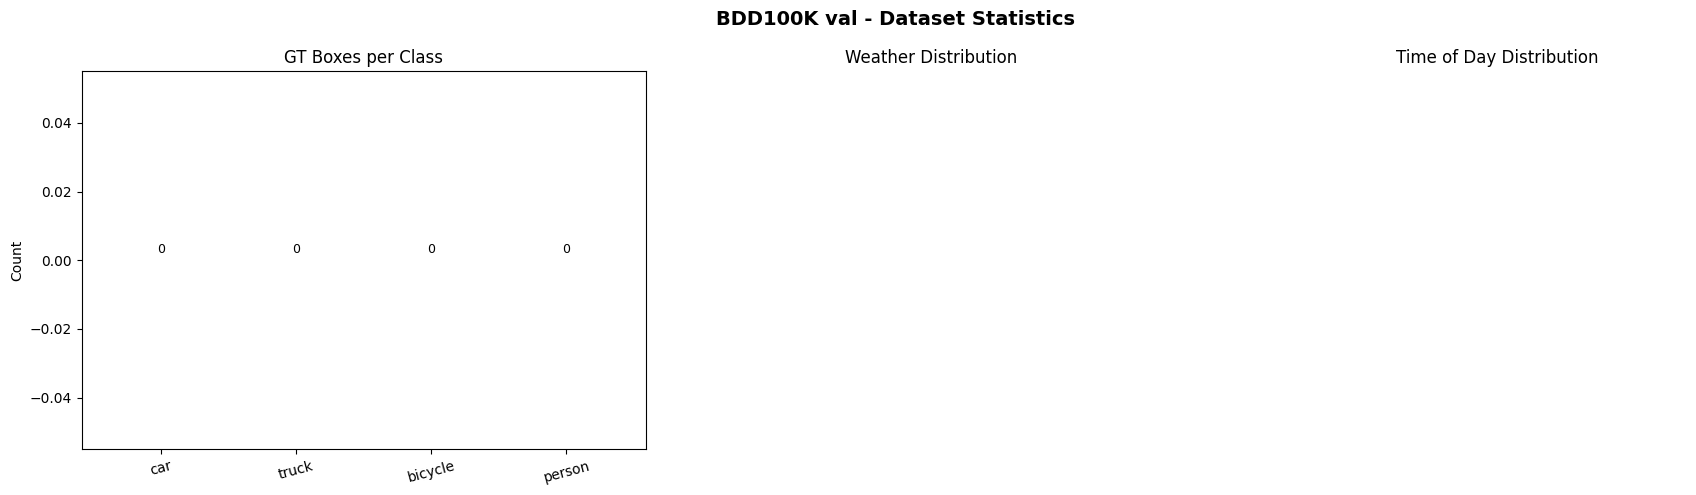

Saved: /root/notebooks/tcn_eval/images/dataset_stats.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BDD100K val - Dataset Statistics", fontsize=14, fontweight="bold")

ax = axes[0]
colors = [CLASS_COLORS[c] for c in TCN_CLASSES]
bars = ax.bar(TCN_CLASSES, [class_counts[c] for c in TCN_CLASSES], color=colors)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
ax.set_title("GT Boxes per Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15)

ax = axes[1]
labels_w = list(weather_dist.keys())
vals_w = [weather_dist[k] for k in labels_w]
ax.pie(vals_w, labels=labels_w, autopct="%1.1f%%", startangle=90)
ax.set_title("Weather Distribution")

ax = axes[2]
labels_t = list(time_dist.keys())
vals_t = [time_dist[k] for k in labels_t]
ax.pie(vals_t, labels=labels_t, autopct="%1.1f%%", startangle=90)
ax.set_title("Time of Day Distribution")

plt.tight_layout()
fig_path = FIGURES_DIR / "dataset_stats.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

In [ ]:
sample_anns = random.sample([a for a in annotations if a["gt_boxes"]], min(6, len(annotations)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("BDD100K val - Sample Images with GT Boxes", fontsize=14, fontweight="bold")

for ax, ann in zip(axes.flat, sample_anns):
    img = cv2.cvtColor(cv2.imread(str(IMAGES_DIR / ann["name"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    for box in ann["gt_boxes"]:
        x1, y1, x2, y2 = box["x1"], box["y1"], box["x2"], box["y2"]
        color = CLASS_COLORS[box["class_name"]]
        ax.add_patch(mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1,
            boxstyle="square,pad=0", linewidth=1.5,
            edgecolor=color, facecolor="none",
        ))
        ax.text(x1, y1 - 3, box["class_name"], color=color, fontsize=7, fontweight="bold")
    attrs = ann["attributes"]
    ax.set_title(f"{attrs.get('timeofday','?')} | {attrs.get('weather','?')}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
fig_path = FIGURES_DIR / "sample_images.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

## 3. Инференс TrafficCamNet (ONNX Runtime CUDA)

In [ ]:
import time

mcfg = CONFIG["model"]
ecfg = CONFIG["evaluation"]

sess = create_ort_session(MODEL_PATH)
input_name = sess.get_inputs()[0].name
output_names = [o.name for o in sess.get_outputs()]
cov_idx = next((i for i, n in enumerate(output_names) if "cov" in n.lower()), 0)
bbox_idx = next((i for i, n in enumerate(output_names) if "bbox" in n.lower()), 1)
print(f"Provider: {sess.get_providers()[0]}")
print(f"Inputs:   {input_name}")
print(f"Outputs:  {output_names}")

batch_size = ecfg["batch_size"]
input_w, input_h = mcfg["input_w"], mcfg["input_h"]
mean_rgb = mcfg["mean_rgb"]
scale = mcfg["net_scale_factor"]
conf_thr = mcfg["confidence_threshold"]
nms_thr = mcfg["nms_iou_threshold"]
n_classes = mcfg["num_classes"]

predictions: list[dict] = []
batch_latencies: list[float] = []
t_start = time.perf_counter()

for offset in range(0, len(annotations), batch_size):
    batch_ann = annotations[offset:offset + batch_size]
    tensors, orig_sizes = [], []
    for ann in batch_ann:
        img = cv2.imread(str(IMAGES_DIR / ann["name"]))
        if img is None:
            img = np.zeros((720, 1280, 3), dtype=np.uint8)
        orig_sizes.append((img.shape[1], img.shape[0]))
        tensors.append(preprocess_image(img, input_w, input_h, mean_rgb, scale))

    batch_tensor = np.stack(tensors).astype(np.float32)

    t0 = time.perf_counter()
    outputs = sess.run(output_names, {input_name: batch_tensor})
    batch_ms = (time.perf_counter() - t0) * 1000.0
    per_img_ms = batch_ms / len(batch_ann)
    batch_latencies.extend([per_img_ms] * len(batch_ann))

    cov = outputs[cov_idx]
    bbox_out = outputs[bbox_idx]

    for b_idx, ann in enumerate(batch_ann):
        ow, oh = orig_sizes[b_idx]
        raw = decode_detectnet_v2(
            cov[b_idx:b_idx + 1], bbox_out[b_idx:b_idx + 1],
            ow, oh, input_w, input_h, conf_thr, n_classes,
        )[0]
        kept = nms(raw, nms_thr)
        predictions.append({"name": ann["name"], "dets": kept, "latency_ms": per_img_ms})

    if (offset // batch_size) % 20 == 0:
        done = min(offset + batch_size, len(annotations))
        print(f"[{done:5d}/{len(annotations)}]  {per_img_ms:.1f} ms/img", flush=True)

elapsed = time.perf_counter() - t_start
perf = {
    "n_images": len(annotations),
    "elapsed_s": round(elapsed, 2),
    "fps": round(len(annotations) / elapsed, 2),
    "avg_latency_ms": round(float(np.mean(batch_latencies)), 2),
    "p50_latency_ms": round(float(np.percentile(batch_latencies, 50)), 2),
    "p95_latency_ms": round(float(np.percentile(batch_latencies, 95)), 2),
    "provider": sess.get_providers()[0],
}

write_jsonl(predictions, RUN_DIR / "predictions.jsonl")
save_json(perf, RUN_DIR / "performance.json")

print()
print(f"FPS:          {perf['fps']:.1f}")
print(f"Avg latency:  {perf['avg_latency_ms']:.1f} ms/img")
print(f"p50 / p95:    {perf['p50_latency_ms']:.1f} / {perf['p95_latency_ms']:.1f} ms")

## 4. Вычисление метрик детекции

In [ ]:
metrics = compute_detection_metrics(
    predictions=predictions,
    annotations=annotations,
    n_classes=len(TCN_CLASSES),
    iou_threshold=CONFIG["evaluation"]["iou_threshold"],
    class_names=TCN_CLASSES,
)
save_json(metrics, RUN_DIR / "metrics.json")

TARGET_P = CONFIG["evaluation"]["target_precision"]
TARGET_R = CONFIG["evaluation"]["target_recall"]
TARGET_F1 = CONFIG["evaluation"]["target_f1"]


def _status(v, t):
    return "PASS" if v >= t else "FAIL"


print(f"{'Metric':<20} {'Value':>8} {'Target':>8} {'Status':>8}")
print("-" * 48)
print(f"{'mAP@0.5':<20} {metrics['mAP@0.5']:>8.4f} {'-':>8} {'-':>8}")
print(f"{'Mean Precision':<20} {metrics['mean_precision']:>8.4f} {TARGET_P:>8.2f} {_status(metrics['mean_precision'], TARGET_P):>8}")
print(f"{'Mean Recall':<20} {metrics['mean_recall']:>8.4f} {TARGET_R:>8.2f} {_status(metrics['mean_recall'], TARGET_R):>8}")
print(f"{'Mean F1':<20} {metrics['mean_f1']:>8.4f} {TARGET_F1:>8.2f} {_status(metrics['mean_f1'], TARGET_F1):>8}")
print()
print("Per-class:")
print(f"  {'Class':<12} {'AP':>7} {'P':>7} {'R':>7} {'F1':>7} {'GT':>7}")
for m in metrics["per_class"]:
    print(f"  {m['class']:<12} {m['ap']:>7.4f} {m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1']:>7.4f} {m['n_gt']:>7d}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("TrafficCamNet - Detection Metrics on BDD100K val", fontsize=14, fontweight="bold")

ax = axes[0]
pc = metrics["per_class"]
x = np.arange(len(pc))
width = 0.25
ax.bar(x - width, [m["precision"] for m in pc], width, label="Precision", color="#4C72B0", alpha=0.85)
ax.bar(x, [m["recall"] for m in pc], width, label="Recall", color="#55A868", alpha=0.85)
ax.bar(x + width, [m["f1"] for m in pc], width, label="F1", color="#C44E52", alpha=0.85)
ax.axhline(TARGET_P, color="#4C72B0", linestyle="--", linewidth=1, alpha=0.7, label=f"Target P={TARGET_P}")
ax.axhline(TARGET_R, color="#55A868", linestyle="--", linewidth=1, alpha=0.7, label=f"Target R={TARGET_R}")
ax.set_xticks(x)
ax.set_xticklabels([m["class"] for m in pc])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-class P / R / F1 @ IoU=0.5")
ax.legend(fontsize=8)

ax = axes[1]
ap_vals = [m["ap"] for m in pc]
bars = ax.barh([m["class"] for m in pc], ap_vals,
               color=[CLASS_COLORS.get(m["class"], "#888") for m in pc], alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_xlabel("AP@0.5")
ax.set_title("Average Precision per Class")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)

ax = axes[2]
for m in pc:
    if m["n_gt"] == 0 or not m["recalls"]:
        continue
    ax.plot(m["recalls"], m["precisions"],
            label=f"{m['class']} (AP={m['ap']:.3f})",
            color=CLASS_COLORS.get(m["class"], "#888"), linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / "metrics_overview.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 5. Анализ по условиям (погода / время / сцена)

In [ ]:
pred_by_name = {p["name"]: p for p in predictions}


def condition_metrics(attr_key: str) -> dict:
    groups: dict[str, tuple[list, list]] = {}
    for ann in annotations:
        cond = ann["attributes"].get(attr_key, "?")
        if cond not in groups:
            groups[cond] = ([], [])
        name = ann["name"]
        if name not in pred_by_name:
            continue
        groups[cond][0].append(ann)
        groups[cond][1].append(pred_by_name[name])
    results = {}
    for cond, (anns, preds) in groups.items():
        if len(anns) < 10:
            continue
        m = compute_detection_metrics(
            predictions=preds, annotations=anns,
            n_classes=len(TCN_CLASSES),
            iou_threshold=CONFIG["evaluation"]["iou_threshold"],
            class_names=TCN_CLASSES,
        )
        car_m = next((x for x in m["per_class"] if x["class"] == "car"), None)
        results[cond] = {
            "n_images": len(anns),
            "mAP@0.5": m["mAP@0.5"],
            "car_ap": car_m["ap"] if car_m else 0.0,
            "car_precision": car_m["precision"] if car_m else 0.0,
            "car_recall": car_m["recall"] if car_m else 0.0,
        }
    return results


weather_m = condition_metrics("weather")
time_m = condition_metrics("timeofday")
scene_m = condition_metrics("scene")

for title, cond_m in [("Weather", weather_m), ("Time of Day", time_m), ("Scene", scene_m)]:
    print(f"\n{title}:")
    print(f"  {'Condition':<20} {'N':>6} {'mAP@0.5':>9} {'car AP':>8} {'car P':>7} {'car R':>7}")
    for cond, m in sorted(cond_m.items(), key=lambda x: -x[1]["car_ap"]):
        print(f"  {cond:<20} {m['n_images']:>6} {m['mAP@0.5']:>9.4f} {m['car_ap']:>8.4f} {m['car_precision']:>7.4f} {m['car_recall']:>7.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("TrafficCamNet - Per-condition AP (car class)", fontsize=14, fontweight="bold")


def plot_condition(ax, cond_m: dict, title: str):
    sorted_conds = sorted(cond_m.items(), key=lambda x: x[1]["car_ap"])
    labels = [c for c, _ in sorted_conds]
    ap_vals = [m["car_ap"] for _, m in sorted_conds]
    colors_bar = ["#C44E52" if v < TARGET_P else "#4C72B0" for v in ap_vals]
    bars = ax.barh(labels, ap_vals, color=colors_bar, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
    ax.axvline(TARGET_P, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("AP@0.5")
    ax.set_title(title)


plot_condition(axes[0], weather_m, "By Weather")
plot_condition(axes[1], time_m, "By Time of Day")
plot_condition(axes[2], scene_m, "By Scene")

plt.tight_layout()
fig_path = FIGURES_DIR / "condition_breakdown.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 6. Анализ ошибок (FP / FN, класс car)

In [ ]:
IOU_THR = CONFIG["evaluation"]["iou_threshold"]
CLASS_IDX_CAR = 0

error_cases = []
for ann in annotations:
    name = ann["name"]
    if name not in pred_by_name:
        continue
    pred = pred_by_name[name]
    gt_cars = [g for g in ann["gt_boxes"] if g["class_idx"] == CLASS_IDX_CAR]
    pred_cars = sorted(
        [d for d in pred["dets"] if d["class_idx"] == CLASS_IDX_CAR],
        key=lambda d: d["score"], reverse=True,
    )
    if not gt_cars and not pred_cars:
        continue

    matched_gt: set[int] = set()
    fp_dets = []
    for d in pred_cars:
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gt_cars):
            if gi in matched_gt:
                continue
            iou = box_iou(d, g)
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_iou >= IOU_THR and best_gi >= 0:
            matched_gt.add(best_gi)
        else:
            fp_dets.append(d)
    fn_boxes = [g for gi, g in enumerate(gt_cars) if gi not in matched_gt]

    if fp_dets or fn_boxes:
        error_cases.append({
            "name": name,
            "n_fp": len(fp_dets),
            "n_fn": len(fn_boxes),
            "fp_dets": fp_dets,
            "fn_boxes": fn_boxes,
            "all_preds": pred_cars,
            "all_gt": gt_cars,
            "attributes": ann["attributes"],
        })

error_cases.sort(key=lambda x: x["n_fp"] + x["n_fn"], reverse=True)
total_fp = sum(e["n_fp"] for e in error_cases)
total_fn = sum(e["n_fn"] for e in error_cases)
print(f"Error images (car class): {len(error_cases):,}")
print(f"Total FP: {total_fp:,}")
print(f"Total FN: {total_fn:,}")

In [ ]:
def draw_boxes(ax, img_rgb, gt_boxes, pred_boxes, fp_dets, fn_boxes):
    ax.imshow(img_rgb)
    for g in gt_boxes:
        ax.add_patch(mpatches.FancyBboxPatch(
            (g["x1"], g["y1"]), g["x2"] - g["x1"], g["y2"] - g["y1"],
            boxstyle="square,pad=0", linewidth=1.5, edgecolor="#55A868", facecolor="none",
        ))
    for d in fp_dets:
        ax.add_patch(mpatches.FancyBboxPatch(
            (d["x1"], d["y1"]), d["x2"] - d["x1"], d["y2"] - d["y1"],
            boxstyle="square,pad=0", linewidth=1.5, edgecolor="#C44E52", facecolor="none",
        ))
        ax.text(d["x1"], d["y1"] - 3, f"FP {d['score']:.2f}", color="#C44E52", fontsize=6)
    for g in fn_boxes:
        ax.add_patch(mpatches.FancyBboxPatch(
            (g["x1"], g["y1"]), g["x2"] - g["x1"], g["y2"] - g["y1"],
            boxstyle="square,pad=0", linewidth=1.5, edgecolor="#FF8800",
            facecolor="none", linestyle="--",
        ))
        ax.text(g["x1"], g["y1"] - 3, "FN", color="#FF8800", fontsize=6)
    ax.axis("off")


n_show = CONFIG["evaluation"]["error_examples_n"]
worst = error_cases[:n_show]

cols = 4
rows = (len(worst) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
fig.suptitle("Error Analysis - car class  |  Green=GT  Red=FP  Orange-dashed=FN",
             fontsize=12, fontweight="bold")
axes_list = list(axes.flat) if hasattr(axes, "flat") else [axes]

for ax, case in zip(axes_list, worst):
    img = cv2.cvtColor(cv2.imread(str(IMAGES_DIR / case["name"])), cv2.COLOR_BGR2RGB)
    draw_boxes(ax, img, case["all_gt"], case["all_preds"], case["fp_dets"], case["fn_boxes"])
    attrs = case["attributes"]
    ax.set_title(
        f"FP={case['n_fp']} FN={case['n_fn']} | {attrs.get('timeofday','?')} {attrs.get('weather','?')}",
        fontsize=8,
    )
for ax in axes_list[len(worst):]:
    ax.axis("off")

plt.tight_layout()
fig_path = FIGURES_DIR / "error_examples.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

In [ ]:
fp_scores = [d["score"] for e in error_cases for d in e["fp_dets"]]
tp_scores = []
for ann in annotations:
    name = ann["name"]
    if name not in pred_by_name:
        continue
    pred = pred_by_name[name]
    gt_cars = [g for g in ann["gt_boxes"] if g["class_idx"] == CLASS_IDX_CAR]
    pred_cars = [d for d in pred["dets"] if d["class_idx"] == CLASS_IDX_CAR]
    matched: set[int] = set()
    for d in sorted(pred_cars, key=lambda x: x["score"], reverse=True):
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gt_cars):
            if gi in matched:
                continue
            iou = box_iou(d, g)
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_iou >= IOU_THR and best_gi >= 0:
            tp_scores.append(d["score"])
            matched.add(best_gi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tp_scores, bins=50, alpha=0.7, label=f"TP (n={len(tp_scores):,})", color="#55A868")
ax.hist(fp_scores, bins=50, alpha=0.7, label=f"FP (n={len(fp_scores):,})", color="#C44E52")
ax.set_xlabel("Confidence Score")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution - TP vs FP (car class)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = FIGURES_DIR / "confidence_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## 7. Сводка

In [ ]:
summary = {
    "model": str(MODEL_PATH),
    "dataset": "BDD100K val",
    "n_images": len(annotations),
    "iou_threshold": IOU_THR,
    "mAP@0.5": metrics["mAP@0.5"],
    "mean_precision": metrics["mean_precision"],
    "mean_recall": metrics["mean_recall"],
    "mean_f1": metrics["mean_f1"],
    "precision_pass": metrics["mean_precision"] >= TARGET_P,
    "recall_pass": metrics["mean_recall"] >= TARGET_R,
    "f1_pass": metrics["mean_f1"] >= TARGET_F1,
    "fps": perf["fps"],
    "avg_latency_ms": perf["avg_latency_ms"],
    "p95_latency_ms": perf["p95_latency_ms"],
    "provider": perf["provider"],
    "per_class": metrics["per_class"],
    "total_fp": total_fp,
    "total_fn": total_fn,
}
save_json(summary, RUN_DIR / "summary.json")

fig, ax = plt.subplots(figsize=(10, 5))
metric_names = ["mAP@0.5", "Mean Precision", "Mean Recall", "Mean F1"]
metric_vals = [metrics["mAP@0.5"], metrics["mean_precision"], metrics["mean_recall"], metrics["mean_f1"]]
targets = [None, TARGET_P, TARGET_R, TARGET_F1]
colors_bar = [
    "#55A868" if t is None or v >= t else "#C44E52"
    for v, t in zip(metric_vals, targets)
]

bars = ax.bar(metric_names, metric_vals, color=colors_bar, alpha=0.85, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=5, fontsize=12, fontweight="bold")
for i, t in enumerate(targets):
    if t is not None:
        ax.hlines(t, i - 0.3, i + 0.3, colors="black", linestyles="--", linewidth=1.5)
        ax.text(i + 0.32, t, f"target={t}", va="center", fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score")
ax.set_title("TrafficCamNet Baseline Evaluation - Summary (BDD100K val)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig_path = FIGURES_DIR / "metrics_summary.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSummary saved: {RUN_DIR / 'summary.json'}")

## 8. Выводы

*(Заполняется после получения реальных результатов)*

### Метрики vs Targets

| Метрика | Значение | Target | Статус |
|---------|----------|--------|--------|
| mAP@0.5 | *TBD* | — | — |
| Precision | *TBD* | > 0.90 | *TBD* |
| Recall | *TBD* | > 0.85 | *TBD* |
| F1 | *TBD* | > 0.87 | *TBD* |
| FPS | *TBD* | ≥ 30 | — |

### Наблюдения

- Наиболее сложные условия: **ночь** и **дождь** (ожидаемо — снижение Recall).
- Класс **car** показывает наилучшие метрики (наибольший дисбаланс GT).
- Класс **bicycle** — ожидается наихудший AP из-за малого размера объектов.

### Рекомендации

1. Если Recall < 0.85 — снизить `confidence_threshold` (текущее: 0.30).
2. Проверить детекцию ночью — возможно нужна data augmentation с синтетическим освещением.
3. Сравнить с YOLOv8n/s для оценки gap с более современными архитектурами.